# Germany New Passenger Vehicle Registrations By Price

In Germany, the Kraftfahrtbundesamt (KBA) publishes monthly numbers on passenger vehicle registrations by model and fuel type in their FZ 8 publication:

Neuzulassungen von Kraftfahrzeugen und Kraftfahrzeuganhängern  
https://www.kba.de/DE/Statistik/Produktkatalog/produkte/Fahrzeuge/fz8/fz8_gentab.html

I wanted to see how the fraction of electric vehicles among new registrations varies with price.  
Price data for all models was acquired from the ADAC.

The data is combined to produce the CSV in `data/de/car_registrations_last_month_with_price_and_fractions.csv`

## Visualizations

[Anteil Antriebsarten nach Listenpreis im August 2025 von 10 - 120k](https://www.datawrapper.de/_/PSqha/)
<iframe title="Anteil Antriebsarten nach Listenpreis im August 2025" aria-label="Scatterplot" id="datawrapper-chart-PSqha" src="https://datawrapper.dwcdn.net/PSqha/3/" scrolling="no" frameborder="0" style="width: 0; min-width: 100% !important; border: none;" height="805" data-external="1"></iframe><script type="text/javascript">!function(){"use strict";window.addEventListener("message",function(a){if(void 0!==a.data["datawrapper-height"]){var e=document.querySelectorAll("iframe");for(var t in a.data["datawrapper-height"])for(var r,i=0;r=e[i];i++)if(r.contentWindow===a.source){var d=a.data["datawrapper-height"][t]+"px";r.style.height=d}}})}();
</script>

[Anteil Antriebsarten nach Listenpreis im August 2025 von 15 - 75k](https://www.datawrapper.de/_/G1LsH/)
<iframe title="Anteil Antriebsarten nach Listenpreis im August 2025 (Detail)" aria-label="Scatterplot" id="datawrapper-chart-G1LsH" src="https://datawrapper.dwcdn.net/G1LsH/3/" scrolling="no" frameborder="0" style="width: 0; min-width: 100% !important; border: none;" height="807" data-external="1"></iframe><script type="text/javascript">!function(){"use strict";window.addEventListener("message",function(a){if(void 0!==a.data["datawrapper-height"]){var e=document.querySelectorAll("iframe");for(var t in a.data["datawrapper-height"])for(var r,i=0;r=e[i];i++)if(r.contentWindow===a.source){var d=a.data["datawrapper-height"][t]+"px";r.style.height=d}}})}();
</script>

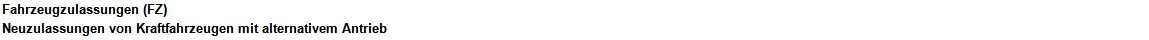

In [1]:
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import de_kba_datagrabber as kba
from adac_aggregate import get_aggregated_adac_price_data
from utils import PowerType
from plot_utils import draw_pie

In [2]:
kba.ensure_up_to_date()
ev_data_raw = kba.fz8_3_models_get()
adac_price_data = get_aggregated_adac_price_data()

August 2025


In [3]:
# Group everything under ICE; Other now only is Hydrogen pretty much
ev_data = ev_data_raw.copy()
ev_data[PowerType.ICE] = ev_data[PowerType.ICE_P] + ev_data[PowerType.ICE_D] + ev_data[PowerType.HEV] + ev_data[PowerType.CNG] + ev_data[PowerType.LPG]
#ev_data[PowerType.Gas] = ev_data[PowerType.CNG] + ev_data[PowerType.LPG]
#ev_data[PowerType.Other] += 
del ev_data[PowerType.ICE_P]
del ev_data[PowerType.ICE_D]
del ev_data[PowerType.CNG]
del ev_data[PowerType.LPG]
del ev_data[PowerType.HEV]
ev_data.stack()

DACIA SPRING     PHEV       0
                 BEV      315
                 Other      0
                 ICE        0
FIAT 500         PHEV       0
                         ... 
MERCEDES UNIMOG  ICE        1
RENAULT MASTER   PHEV       0
                 BEV        0
                 Other      0
                 ICE       49
Length: 1372, dtype: int64

In [4]:
adac_fuel_map = {
    'Super': PowerType.ICE,
    'Super Plus': PowerType.ICE,
    'Super / Super': PowerType.ICE,
    'Diesel': PowerType.ICE,
    'Super / Strom': PowerType.PHEV,
    'Super Plus / Strom': PowerType.PHEV,
    'Diesel / Strom': PowerType.PHEV,
    'Strom / Super': PowerType.PHEV,
    'Strom / Super Plus': PowerType.PHEV,
    'Flüssiggas': PowerType.ICE,
    'Erdgas / Super': PowerType.ICE,
    'Strom': PowerType.BEV,
    'Wasserstoff': PowerType.Other,
}

# Re-group by mapped fuel types and recalculate min, max, avg

mapped_index = pd.MultiIndex.from_tuples(
    [(name, adac_fuel_map.get(fuel)) for name, fuel in adac_price_data.index],
    names=['NAME', 'fuelType']
)

adac_price_regrouped = adac_price_data.copy()
adac_price_regrouped.index = mapped_index

# Recalculate stats per NAME and new fuelType
adac_price_regrouped = adac_price_regrouped.groupby(level=['NAME', 'fuelType']).agg(
    min_price=('min_price', 'min'),
    max_price=('max_price', 'max'),
    avg_price=('avg_price', 'mean'),
    med_price=('med_price', 'median'),
)

# Where there is PHEV data but no ICE data, copy PHEV data to ICE
# This is because the data unfortunately does not properly distinguish between PHEV and mild EVs, so if no ICE data is available, use PHEV data instead
to_append = []
for name in adac_price_regrouped.index.get_level_values('NAME').unique():
    has_ice = ((name, PowerType.ICE) in adac_price_regrouped.index)
    has_phev = ((name, PowerType.PHEV) in adac_price_regrouped.index)
    if (not has_ice) and has_phev:
        phev_row = adac_price_regrouped.loc[(name, PowerType.PHEV)]
        to_append.append(((name, PowerType.ICE), phev_row.to_dict()))

if to_append:
    add_df = pd.DataFrame.from_dict({k: v for k, v in to_append}, orient='index')
    add_df.index = pd.MultiIndex.from_tuples(add_df.index, names=['NAME', 'fuelType'])
    adac_price_regrouped = pd.concat([adac_price_regrouped, add_df], axis=0)

adac_price_regrouped.sort_index(inplace=True)
adac_price_regrouped


min_price max_price     avg_price med_price
NAME               fuelType                                            
ALFA ROMEO GIULIA  ICE        56000.0   66500.0  61333.333333   61500.0
ALFA ROMEO JUNIOR  BEV        39500.0   48500.0       43750.0   43500.0
                   ICE        30450.0   40000.0       35480.0   36500.0
ALFA ROMEO STELVIO ICE        60600.0   71100.0  65933.333333   66100.0
ALFA ROMEO TONALE  ICE        40800.0   52800.0  46883.333333   47050.0
...                               ...       ...           ...       ...
VW TRANSPORTER     ICE        43768.0   88995.0  63940.718468   62484.0
                   PHEV       55258.0  102847.0       71282.0   64037.0
XPENG G6           BEV        47600.0   51600.0       49600.0   49600.0
XPENG G9           BEV        59600.0   72600.0  65266.666667   63600.0
XPENG P7           BEV        49600.0   58600.0       54100.0   54100.0

[604 rows x 4 columns]

Now that both datasources have been brought into the same grouping and format, merge them

In [5]:
# For every non-zero entry in ev_data.stack(), add matching price columns from adac_price_regrouped; drop zeros
ev_full_data = ev_data.stack()
ev_full_data = ev_full_data[ev_full_data != 0]

# Ensure MultiIndex aligned with (NAME, fuelType)
ev_full_data.index = pd.MultiIndex.from_tuples(ev_full_data.index, names=['NAME', 'fuelType'])

# Join with price data and drop entries without price info
ev_full_data = ev_full_data.to_frame('registrations').join(adac_price_regrouped, how='left')

missing_data_entries = ev_full_data[ev_full_data['med_price'].isna()].copy()
missing_data_entries.sort_values(by=['registrations'], ascending=False, inplace=True)

ev_full_data.dropna(subset=['min_price', 'max_price', 'avg_price', 'med_price'], inplace=True)

missing_data_entries

,,registrations,min_price,max_price,avg_price,med_price
NAME,fuelType,,,,,
MAN TGE,ICE,153,NaN,NaN,NaN,NaN
BMW XM,PHEV,69,NaN,NaN,NaN,NaN
FIAT ULYSSE,ICE,60,NaN,NaN,NaN,NaN
SONSTIGE,ICE,60,NaN,NaN,NaN,NaN
IVECO DAILY,ICE,53,NaN,NaN,NaN,NaN
PEUGEOT 3008,PHEV,26,NaN,NaN,NaN,NaN
TOGG T10X,BEV,16,NaN,NaN,NaN,NaN
BENTLEY CONTINENTAL,PHEV,9,NaN,NaN,NaN,NaN
BENTLEY BENTAYGA,PHEV,8,NaN,NaN,NaN,NaN


In [6]:
# For every entry in ev_full_data, calculate the fraction of bev, ice and phev within 10k of the average_price
comparison_range_abs = 7000  # price range
comparison_range_factor = 0.1
# Jitter the data depending on how many vehicles of the same type there are nearby to make the dots easier to distinguish in visualizations
jitter_comp_range_abs = 2000  # consider cars within +- this range for jitter calculation
jitter_const = 0.005
jitter_factor = 0.7
price_to_use = 'med_price'

np.random.seed(42)

# Reset index to work with the data more easily
ev_full_data_w_fractions = ev_full_data.reset_index()

total_registrations = ev_full_data_w_fractions['registrations'].sum()

# Initialize the fraction columns
ev_full_data_w_fractions['frac_bev_nearby'] = 0.0
ev_full_data_w_fractions['frac_ice_nearby'] = 0.0
ev_full_data_w_fractions['frac_phev_nearby'] = 0.0
ev_full_data_w_fractions['frac_other_nearby'] = 0.0
ev_full_data_w_fractions['frac_nearby'] = 0.0
ev_full_data_w_fractions['frac_nearby_jittered'] = 0.0

# For each entry, calculate fractions within 10k of its average_price
for idx, row in ev_full_data_w_fractions.iterrows():
    target_price = row[price_to_use]
    comp_range = comparison_range_abs + comparison_range_factor * target_price

    # Find all entries within 10k of this price
    price_mask = (ev_full_data_w_fractions[price_to_use] >= target_price - comp_range) & (ev_full_data_w_fractions[price_to_use] <= target_price + comp_range)
    nearby_data = ev_full_data_w_fractions[price_mask]

    # Calculate total registrations for each fuel type within the range
    bev_total = nearby_data[nearby_data['fuelType'] == PowerType.BEV]['registrations'].sum()
    ice_total = nearby_data[nearby_data['fuelType'] == PowerType.ICE]['registrations'].sum()
    phev_total = nearby_data[nearby_data['fuelType'] == PowerType.PHEV]['registrations'].sum()
    other_total = nearby_data[nearby_data['fuelType'] == PowerType.Other]['registrations'].sum()
    
    jitter_nearby_data = ev_full_data_w_fractions[(ev_full_data_w_fractions[price_to_use] >= target_price - jitter_comp_range_abs) & (ev_full_data_w_fractions[price_to_use] <= target_price + jitter_comp_range_abs)]
    jitter_same_total = jitter_nearby_data[jitter_nearby_data['fuelType'] == row['fuelType']]['registrations'].sum()

    # Calculate total registrations within the range
    total_nearby = bev_total + ice_total + phev_total

    # Calculate fractions (avoid division by zero)
    if total_nearby > 0:
        ev_full_data_w_fractions.loc[idx, 'frac_bev_nearby'] = bev_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_ice_nearby'] = ice_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_phev_nearby'] = phev_total / total_nearby
        ev_full_data_w_fractions.loc[idx, 'frac_other_nearby'] = other_total / total_nearby
        frac_nearby = ev_full_data_w_fractions.loc[idx, f'frac_{row['fuelType'].lower()}_nearby']
        ev_full_data_w_fractions.loc[idx, 'frac_nearby'] = frac_nearby
        # jitter fraction value, but never outside [0,1] bounds
        ev_full_data_w_fractions.loc[idx, 'frac_nearby_jittered'] = (frac_nearby +
            min(max(
                ((jitter_same_total / total_registrations * jitter_factor + jitter_const) * (np.random.rand()*2-1)),
                -frac_nearby), 1-frac_nearby)
            )

# Set the index back and update ev_full_data
ev_full_data_w_fractions.set_index(['NAME', 'fuelType'], inplace=True)

ev_full_data_w_fractions.to_csv('data/de/car_registrations_last_month_with_price_and_fractions.csv')
ev_full_data_w_fractions

registrations min_price max_price     avg_price  \
NAME           fuelType                                                    
DACIA SPRING   BEV                 315   16900.0   19900.0       18400.0   
FIAT 500       BEV                 928   24990.0   37990.0  31061.428571   
FIAT PANDA     ICE                  84   18990.0   24990.0  21823.333333   
HYUNDAI I 10   ICE                1193   16990.0   22190.0      19838.75   
KIA PICANTO    ICE                 736   17850.0   22550.0       20250.0   
...                                ...       ...       ...           ...   
VW ID. BUZZ    BEV                 510   49998.0   75065.0  61397.727273   
VW TRANSPORTER PHEV                423   55258.0  102847.0       71282.0   
               BEV                  24   59310.0   79724.0  68482.522222   
               ICE                1848   43768.0   88995.0  63940.718468   
RENAULT MASTER ICE                  49   41995.0   54014.0  48515.828125   

                        med_price  frac_bev_nearby  frac_ice_nearby  \
NAME           fuelType                                               
DACIA SPRING   BEV        18400.0         0.109675         0.890325   
FIAT 500       BEV        30990.0         0.089121         0.904250   
FIAT PANDA     ICE        21490.0         0.071454         0.928546   
HYUNDAI I 10   ICE        19575.0         0.084090         0.915910   
KIA PICANTO    ICE        20550.0         0.076047         0.923953   
...                           ...              ...              ...   
VW ID. BUZZ    BEV        61077.0         0.248624         0.570822   
VW TRANSPORTER PHEV       64037.0         0.265578         0.537135   
               BEV        67895.5         0.252645         0.472174   
               ICE        62484.0         0.244481         0.565125   
RENAULT MASTER ICE        48659.0         0.236146         0.641975   

                         frac_phev_nearby  frac_other_nearby  frac_nearby  \
NAME           fuelType                                                     
DACIA SPRING   BEV               0.000000           0.000000     0.109675   
FIAT 500       BEV               0.006629           0.000000     0.089121   
FIAT PANDA     ICE               0.000000           0.000000     0.928546   
HYUNDAI I 10   ICE               0.000000           0.000000     0.915910   
KIA PICANTO    ICE               0.000000           0.000000     0.923953   
...                                   ...                ...          ...   
VW ID. BUZZ    BEV               0.180554           0.000000     0.248624   
VW TRANSPORTER PHEV              0.197287           0.000034     0.197287   
               BEV               0.275181           0.000044     0.252645   
               ICE               0.190394           0.000030     0.565125   
RENAULT MASTER ICE               0.121879           0.000000     0.641975   

                         frac_nearby_jittered  
NAME           fuelType                        
DACIA SPRING   BEV                   0.107631  
FIAT 500       BEV                   0.101023  
FIAT PANDA     ICE                   0.943902  
HYUNDAI I 10   ICE                   0.920943  
KIA PICANTO    ICE                   0.902809  
...                                       ...  
VW ID. BUZZ    BEV                   0.246374  
VW TRANSPORTER PHEV                  0.203227  
               BEV                   0.247923  
               ICE                   0.564798  
RENAULT MASTER ICE                   0.580471  

[457 rows x 11 columns]